# 4. The axis that does not start at zero

**The mistake in one sentence:** a bar chart compares bar lengths, so cutting the bottom of the axis lies about the difference.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/CS42org/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

On 31 July 2012, Fox Business showed the top US tax rate going from 35 percent to 39.6 percent if the Bush tax cuts expired. The vertical axis started at 34. The second bar looked five times taller than the first. The real difference was 4.6 points.

In [3]:
fox = pd.read_csv(dms.DATA / "fox_tax_chart_2012.csv")
fox

,label,top_tax_rate_percent
0,Now,35.0
1,Jan 1 2013,39.6


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, ylim, title in zip(axes, [(34, 40.5), (0, 45)], ["As shown on air: axis starts at 34", "Honest version: axis starts at 0"]):
    ax.bar(fox.label, fox.top_tax_rate_percent, color=[dms.GREY, dms.BLUE], width=0.55)
    ax.set_ylim(*ylim); ax.set_title(title)
    for x, v in zip(fox.label, fox.top_tax_rate_percent):
        ax.text(x, v + (ylim[1] - ylim[0]) * 0.02, f"{v}%", ha="center", weight="bold")
dms.save(fig, "04_truncated_axis.png")
plt.show()

## Animated figure

The bottom of the axis slides from 34 down to 0. Nothing else changes.

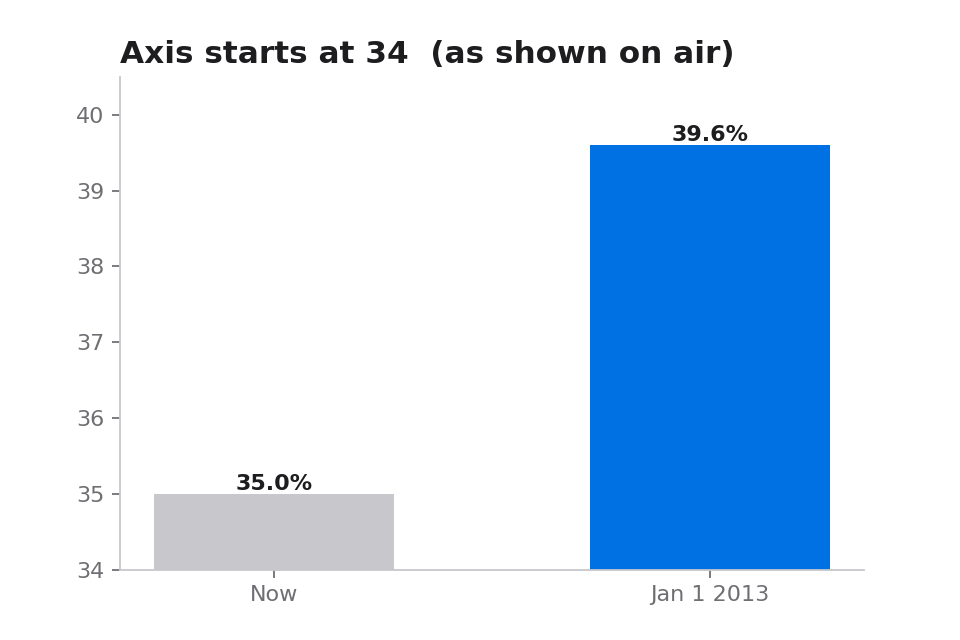

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(fox.label, fox.top_tax_rate_percent, color=[dms.GREY, dms.BLUE], width=0.55)
labels = [ax.text(x, v, f"{v}%", ha="center", va="bottom", weight="bold") for x, v in zip(fox.label, fox.top_tax_rate_percent)]
title = ax.set_title("")
bottoms = np.concatenate([np.full(12, 34), 34 * (1 - np.linspace(0, 1, 40)) ** 2, np.zeros(14)])

def update(i):
    b = bottoms[i]
    ax.set_ylim(b, 45 if b < 33 else 40.5)
    title.set_text(f"Axis starts at {b:.0f}" + ("  (as shown on air)" if b > 33 else "  (the gap is 4.6 points)" if b < 1 else ""))
    return bars

anim = FuncAnimation(fig, update, frames=len(bottoms), interval=80)
gif = dms.FIG / "04_axis_slides.gif"
anim.save(gif, writer=PillowWriter(fps=10))
plt.close(fig)
display(Image(filename=str(gif)))

## The twin trick: dates out of order

In May 2020 the Georgia Department of Public Health published a chart of daily virus cases where the dates were not in order. The tallest bar was on the left, the shortest on the right, so cases looked like they were falling every day.

The data below is illustrative, not the real Georgia counts. The trick is the same. Look at how it is made: one `sort_values` call.

In [6]:
ga = pd.read_csv(dms.DATA / "georgia_cases_illustrative.csv", parse_dates=["date"])
tricked = ga.sort_values("cases", ascending=False)
honest = ga.sort_values("date")
tricked.head()

,date,cases
3,2020-04-29,118
1,2020-04-27,112
5,2020-05-01,106
7,2020-05-03,101
0,2020-04-26,95


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, frame, title in zip(axes, [tricked, honest], ["Sorted by size: cases look like they fall", "Sorted by date: the truth"]):
    ax.bar(range(len(frame)), frame.cases, color=dms.BLUE, width=0.7)
    ax.set_xticks(range(len(frame)), frame.date.dt.strftime("%d %b"), rotation=60, fontsize=8)
    ax.set_title(title); ax.set_ylabel("daily cases")
dms.save(fig, "04_dates_out_of_order.png")
plt.show()

## Better method

Bars start at zero. Dates go in order. If a small change matters, plot the change itself and write the number in words: 4.6 points.

## Ask this

Where does the chart start? Are the dates in order?